# BEGAN

**Load and Preprocess**
- Loading Data
- Normalizing pixel values : [0,255] -> [0,1] -> [-1,1]

In [1]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


def load_data(batch_size=64):

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,))
    ])
    
    train_dataset = datasets.MNIST(
        root='./data', 
        train=True, 
        transform=transform,
        download = True
    )
    
    dataloader = DataLoader(
        dataset=train_dataset, 
        batch_size=batch_size, 
        shuffle=True, 
        drop_last=True 
    )
    
    return dataloader

**helper function** that we use to plot images (used both for training data visualization and generated data)

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import math
import torch

def plot_images(images, num_cols, title):

    if isinstance(images, torch.Tensor):
        images = [img for img in images]
        
    num_images = len(images)
    if num_images == 0:
        print("No images to plot.")
        return
        
    num_rows = math.ceil(num_images / num_cols)
    
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(num_cols, num_rows))
    if title:
        fig.suptitle(title, fontsize=16)
    

    if num_rows == 1 and num_cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    for i, ax in enumerate(axes):
        if i < num_images:

            normalized_img = images[i].detach().cpu().squeeze()
            
            unnormalized_img = (normalized_img + 1) / 2 
            
            unnormalized_img = torch.clamp(unnormalized_img, 0, 1)
            
            ax.imshow(unnormalized_img, cmap='gray')
            
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

**sanity check**

Batch image shape: torch.Size([64, 1, 28, 28])
Value range: Min = -1.0, Max = 1.0


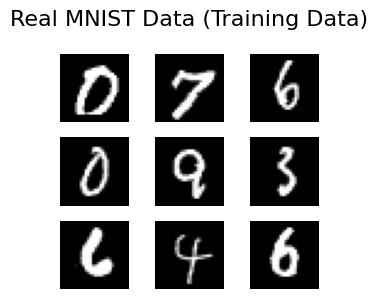

In [3]:
BATCH_SIZE = 64
dataloader = load_data(batch_size=BATCH_SIZE)
real_images, labels = next(iter(dataloader))

print(f"Batch image shape: {real_images.shape}") 
print(f"Value range: Min = {real_images.min().item()}, Max = {real_images.max().item()}")


plot_images(real_images[:9] , 3, "Real MNIST Data (Training Data)")

**Generator Architecture**

In [ ]:
import torch
import torch.nn as nn
class Generator(nn.Module):
    def __init__(self, latent_dim=100, h=64, channels=1):
        super(Generator, self).__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, h * 4, 4, 1, 0, bias=False),
            nn.BatchNorm2d(h * 4),
            nn.ReLU(True),
            nn.ConvTranspose2d(h * 4, h * 2, 3, 2, 1, bias=False),
            nn.BatchNorm2d(h * 2),
            nn.ReLU(True),
            nn.ConvTranspose2d(h * 2, h, 4, 2, 1, bias=False),
            nn.BatchNorm2d(h),
            nn.ReLU(True),
            nn.ConvTranspose2d(h, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        x = x.view(x.size(0), x.size(1), 1, 1)
        return self.net(x)

**Discriminator Architecture**

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, latent_dim=256, h=64, channels=1):
        super(Discriminator, self).__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(channels, h, 4, 2, 1, bias=True),       
            nn.ELU(inplace=True),
            nn.Conv2d(h, h * 2, 4, 2, 1, bias=True),         
            nn.ELU(inplace=True),
            nn.Conv2d(h * 2, h * 4, 3, 2, 1, bias=True),      
            nn.ELU(inplace=True),
            nn.Conv2d(h * 4, latent_dim, 3, 2, 0, bias=True)  
        )
        
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(latent_dim, h * 4, 4, 2, 0, bias=True), 
            nn.ELU(inplace=True),
            nn.ConvTranspose2d(h * 4, h * 2, 3, 2, 1, bias=True), 
            nn.ELU(inplace=True),
            nn.ConvTranspose2d(h * 2, h, 4, 2, 1, bias=True),    
            nn.ELU(inplace=True),
            nn.ConvTranspose2d(h, channels, 4, 2, 1, bias=True)  ‍
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat

**Weight Initialization**

drawing weights from a normal distribution with a mean of 0 and a standard deviation of 0.02 for Conv layers and mean 1 , std 0.02 for BatchNorm

In [6]:
import torch.nn.init as init

def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1 or classname.find('ConvTranspose') != -1:
        init.kaiming_normal_(m.weight.data, mode='fan_out', nonlinearity='leaky_relu')
        if hasattr(m, 'bias') and m.bias is not None:
            init.constant_(m.bias.data, 0.0)
    elif classname.find('BatchNorm') != -1:
        init.normal_(m.weight.data, mean=1.0, std=0.02)
        init.constant_(m.bias.data, 0.0)

**Instance & sanity check**

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

latent_dim = 256

netG = Generator(latent_dim=latent_dim).to(device)
netD = Discriminator(latent_dim=latent_dim).to(device)

netG.apply(weights_init)
netD.apply(weights_init)

print(netG)
print(netD)

Generator(
  (net): Sequential(
    (0): ConvTranspose2d(256, 256, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(256, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(64, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): Tanh()
  )
)
Discriminator(
  (encoder): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ELU(alpha=1.0, inplace=True)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=

**Configs**

In [8]:
import torch.optim as optim
k_t = 0.0
lr = 3.5e-5
gamma = 0.7
lambda_k = 0.001
num_epochs = 30

optimizerD = optim.Adam(netD.parameters(), lr=lr, betas=(0.5, 0.999))
optimizerG = optim.Adam(netG.parameters(), lr=lr, betas=(0.5, 0.999))

fixed_noise = torch.randn(64, latent_dim, device=device)

l1_loss = nn.L1Loss()

G_losses = []
D_losses = []
M_values = []
k_values = []

**Training Loop**

$$\mathcal{L}(v) = |v - D(v)|$$
$$Loss_D = \mathcal{L}(x) - k_t \cdot \mathcal{L}(G(z))$$
$$Loss_G = \mathcal{L}(G(z))$$
$$k_{t+1} = k_t + \lambda \cdot (\gamma \mathcal{L}(x) - \mathcal{L}(G(z)))$$
$$\gamma = \frac{\mathbb{E}[\mathcal{L}(G(z))]}{\mathbb{E}[\mathcal{L}(x)]} = \frac{\text{Average Error on Fakes}}{\text{Average Error on Reals}}$$

$$M = \mathcal{L}(x) + |\gamma \mathcal{L}(x) - \mathcal{L}(G(z))|$$

[0/30][0/937] Loss_D: 0.9460 Loss_G: 0.3649 M: 1.2433 k: 0.0100
[0/30][400/937] Loss_D: 0.2403 Loss_G: 0.0254 M: 0.3857 k: 0.0602
[0/30][800/937] Loss_D: 0.2187 Loss_G: 0.0249 M: 0.3518 k: 0.1182


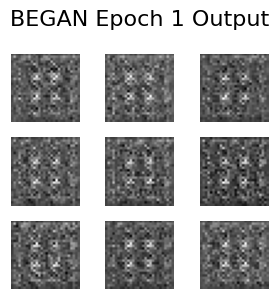

[1/30][0/937] Loss_D: 0.1992 Loss_G: 0.0534 M: 0.2972 k: 0.1336
[1/30][400/937] Loss_D: 0.1753 Loss_G: 0.2318 M: 0.2880 k: 0.0403
[1/30][800/937] Loss_D: 0.1706 Loss_G: 0.1362 M: 0.1882 k: 0.0177


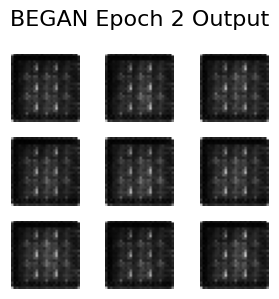

[2/30][0/937] Loss_D: 0.1597 Loss_G: 0.1061 M: 0.1692 k: 0.0145
[2/30][400/937] Loss_D: 0.1562 Loss_G: 0.1205 M: 0.1677 k: 0.0100
[2/30][800/937] Loss_D: 0.1479 Loss_G: 0.1245 M: 0.1692 k: 0.0100


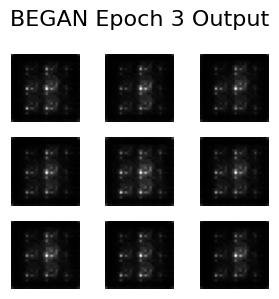

[3/30][0/937] Loss_D: 0.1431 Loss_G: 0.0964 M: 0.1487 k: 0.0100
[3/30][400/937] Loss_D: 0.1326 Loss_G: 0.0503 M: 0.1766 k: 0.0235
[3/30][800/937] Loss_D: 0.1268 Loss_G: 0.0539 M: 0.1660 k: 0.0404


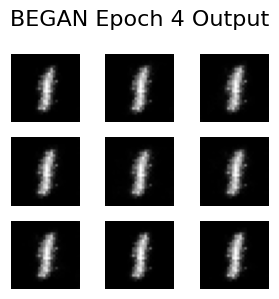

[4/30][0/937] Loss_D: 0.1214 Loss_G: 0.0683 M: 0.1431 k: 0.0434
[4/30][400/937] Loss_D: 0.1165 Loss_G: 0.0721 M: 0.1306 k: 0.0515
[4/30][800/937] Loss_D: 0.1134 Loss_G: 0.0783 M: 0.1199 k: 0.0580


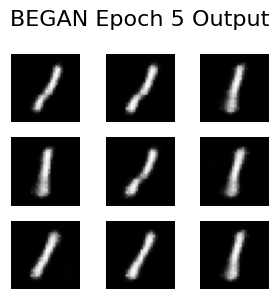

[5/30][0/937] Loss_D: 0.1120 Loss_G: 0.0619 M: 0.1339 k: 0.0614
[5/30][400/937] Loss_D: 0.1040 Loss_G: 0.0569 M: 0.1259 k: 0.0712
[5/30][800/937] Loss_D: 0.1013 Loss_G: 0.0555 M: 0.1230 k: 0.0801


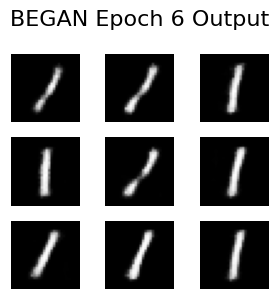

[6/30][0/937] Loss_D: 0.0971 Loss_G: 0.0572 M: 0.1153 k: 0.0827
[6/30][400/937] Loss_D: 0.0925 Loss_G: 0.0480 M: 0.1177 k: 0.0897
[6/30][800/937] Loss_D: 0.0882 Loss_G: 0.0540 M: 0.1043 k: 0.0953


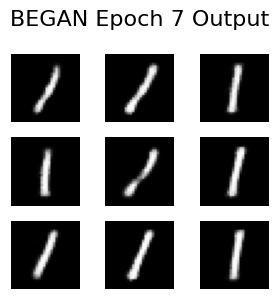

[7/30][0/937] Loss_D: 0.0872 Loss_G: 0.0482 M: 0.1090 k: 0.0970
[7/30][400/937] Loss_D: 0.0885 Loss_G: 0.0582 M: 0.1009 k: 0.1014
[7/30][800/937] Loss_D: 0.0811 Loss_G: 0.0758 M: 0.1016 k: 0.1045


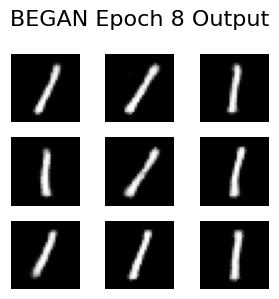

[8/30][0/937] Loss_D: 0.0839 Loss_G: 0.0548 M: 0.0970 k: 0.1055
[8/30][400/937] Loss_D: 0.0777 Loss_G: 0.0497 M: 0.0908 k: 0.1089
[8/30][800/937] Loss_D: 0.0768 Loss_G: 0.0476 M: 0.0929 k: 0.1125


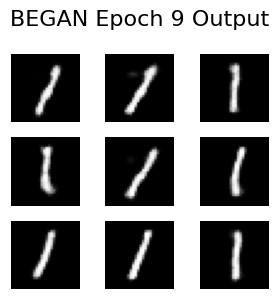

[9/30][0/937] Loss_D: 0.0739 Loss_G: 0.0438 M: 0.0914 k: 0.1138
[9/30][400/937] Loss_D: 0.0803 Loss_G: 0.0619 M: 0.0875 k: 0.1172
[9/30][800/937] Loss_D: 0.0718 Loss_G: 0.0403 M: 0.0937 k: 0.1204


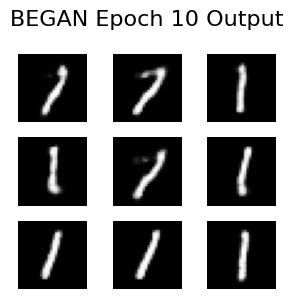

[10/30][0/937] Loss_D: 0.0725 Loss_G: 0.0518 M: 0.0799 k: 0.1213
[10/30][400/937] Loss_D: 0.0683 Loss_G: 0.0477 M: 0.0789 k: 0.1243
[10/30][800/937] Loss_D: 0.0685 Loss_G: 0.0478 M: 0.0785 k: 0.1272


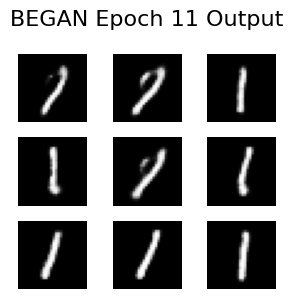

[11/30][0/937] Loss_D: 0.0680 Loss_G: 0.0375 M: 0.0883 k: 0.1282
[11/30][400/937] Loss_D: 0.0682 Loss_G: 0.0490 M: 0.0756 k: 0.1308
[11/30][800/937] Loss_D: 0.0604 Loss_G: 0.0394 M: 0.0732 k: 0.1333


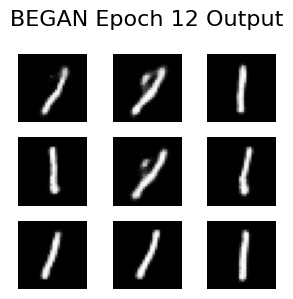

[12/30][0/937] Loss_D: 0.0611 Loss_G: 0.0405 M: 0.0724 k: 0.1342
[12/30][400/937] Loss_D: 0.0616 Loss_G: 0.0461 M: 0.0683 k: 0.1362
[12/30][800/937] Loss_D: 0.0582 Loss_G: 0.0426 M: 0.0661 k: 0.1381


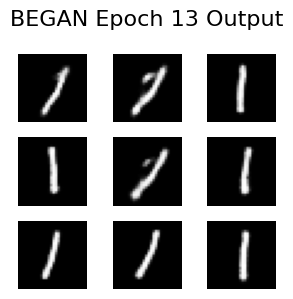

[13/30][0/937] Loss_D: 0.0610 Loss_G: 0.0381 M: 0.0747 k: 0.1387
[13/30][400/937] Loss_D: 0.0621 Loss_G: 0.0401 M: 0.0763 k: 0.1402
[13/30][800/937] Loss_D: 0.0603 Loss_G: 0.0477 M: 0.0674 k: 0.1414


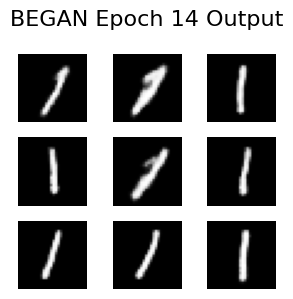

[14/30][0/937] Loss_D: 0.0560 Loss_G: 0.0386 M: 0.0657 k: 0.1419
[14/30][400/937] Loss_D: 0.0584 Loss_G: 0.0408 M: 0.0698 k: 0.1430
[14/30][800/937] Loss_D: 0.0556 Loss_G: 0.0421 M: 0.0638 k: 0.1439


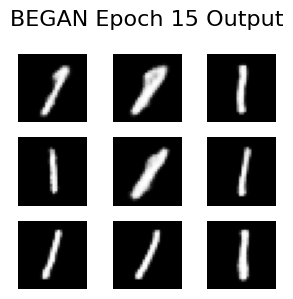

[15/30][0/937] Loss_D: 0.0571 Loss_G: 0.0441 M: 0.0633 k: 0.1442
[15/30][400/937] Loss_D: 0.0557 Loss_G: 0.0461 M: 0.0648 k: 0.1447
[15/30][800/937] Loss_D: 0.0533 Loss_G: 0.0451 M: 0.0628 k: 0.1452


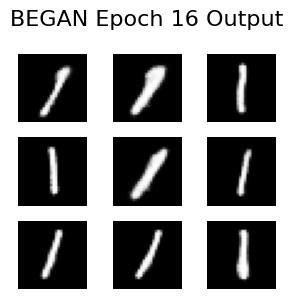

[16/30][0/937] Loss_D: 0.0560 Loss_G: 0.0442 M: 0.0625 k: 0.1454
[16/30][400/937] Loss_D: 0.0549 Loss_G: 0.0458 M: 0.0639 k: 0.1460
[16/30][800/937] Loss_D: 0.0509 Loss_G: 0.0415 M: 0.0586 k: 0.1469


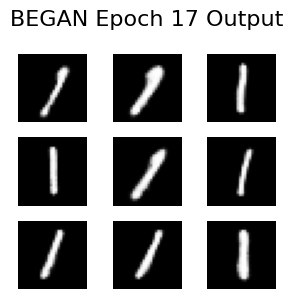

[17/30][0/937] Loss_D: 0.0544 Loss_G: 0.0386 M: 0.0626 k: 0.1472
[17/30][400/937] Loss_D: 0.0499 Loss_G: 0.0336 M: 0.0602 k: 0.1481
[17/30][800/937] Loss_D: 0.0530 Loss_G: 0.0408 M: 0.0582 k: 0.1489


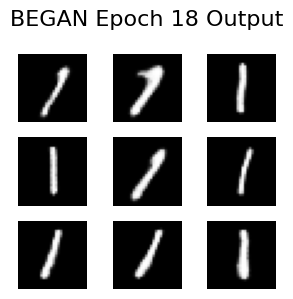

[18/30][0/937] Loss_D: 0.0521 Loss_G: 0.0420 M: 0.0592 k: 0.1492
[18/30][400/937] Loss_D: 0.0503 Loss_G: 0.0388 M: 0.0568 k: 0.1501
[18/30][800/937] Loss_D: 0.0513 Loss_G: 0.0393 M: 0.0572 k: 0.1509


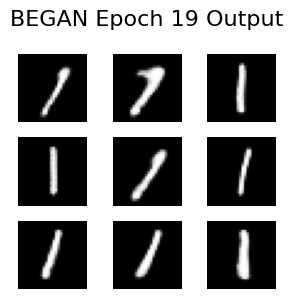

[19/30][0/937] Loss_D: 0.0512 Loss_G: 0.0372 M: 0.0587 k: 0.1511
[19/30][400/937] Loss_D: 0.0476 Loss_G: 0.0323 M: 0.0592 k: 0.1519
[19/30][800/937] Loss_D: 0.0476 Loss_G: 0.0419 M: 0.0577 k: 0.1527


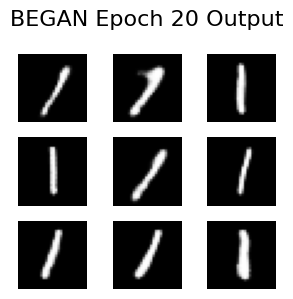

[20/30][0/937] Loss_D: 0.0490 Loss_G: 0.0339 M: 0.0582 k: 0.1529
[20/30][400/937] Loss_D: 0.0479 Loss_G: 0.0356 M: 0.0570 k: 0.1536
[20/30][800/937] Loss_D: 0.0494 Loss_G: 0.0410 M: 0.0573 k: 0.1544


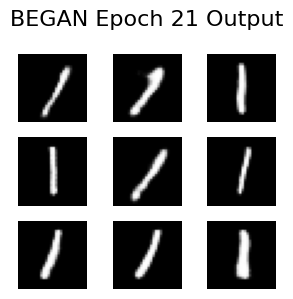

[21/30][0/937] Loss_D: 0.0436 Loss_G: 0.0293 M: 0.0540 k: 0.1546
[21/30][400/937] Loss_D: 0.0489 Loss_G: 0.0351 M: 0.0576 k: 0.1551
[21/30][800/937] Loss_D: 0.0464 Loss_G: 0.0371 M: 0.0527 k: 0.1559


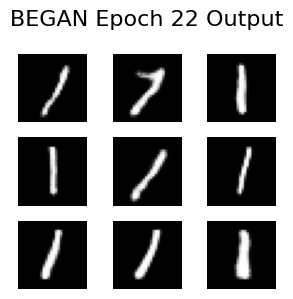

[22/30][0/937] Loss_D: 0.0472 Loss_G: 0.0393 M: 0.0549 k: 0.1562
[22/30][400/937] Loss_D: 0.0444 Loss_G: 0.0358 M: 0.0507 k: 0.1568
[22/30][800/937] Loss_D: 0.0443 Loss_G: 0.0331 M: 0.0517 k: 0.1574


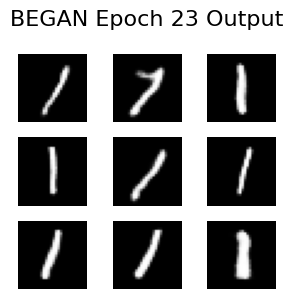

[23/30][0/937] Loss_D: 0.0447 Loss_G: 0.0369 M: 0.0519 k: 0.1576
[23/30][400/937] Loss_D: 0.0431 Loss_G: 0.0354 M: 0.0500 k: 0.1581
[23/30][800/937] Loss_D: 0.0423 Loss_G: 0.0327 M: 0.0472 k: 0.1587


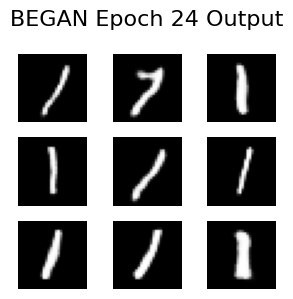

[24/30][0/937] Loss_D: 0.0448 Loss_G: 0.0377 M: 0.0528 k: 0.1589
[24/30][400/937] Loss_D: 0.0435 Loss_G: 0.0354 M: 0.0499 k: 0.1594
[24/30][800/937] Loss_D: 0.0434 Loss_G: 0.0323 M: 0.0510 k: 0.1599


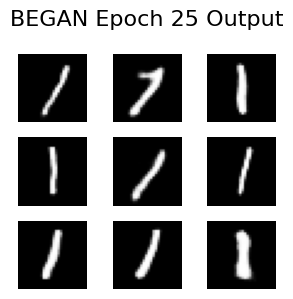

[25/30][0/937] Loss_D: 0.0431 Loss_G: 0.0322 M: 0.0494 k: 0.1601
[25/30][400/937] Loss_D: 0.0434 Loss_G: 0.0280 M: 0.0540 k: 0.1605
[25/30][800/937] Loss_D: 0.0427 Loss_G: 0.0329 M: 0.0476 k: 0.1610


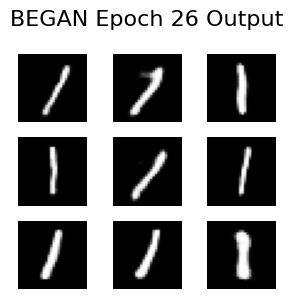

[26/30][0/937] Loss_D: 0.0425 Loss_G: 0.0336 M: 0.0480 k: 0.1612
[26/30][400/937] Loss_D: 0.0416 Loss_G: 0.0329 M: 0.0468 k: 0.1615
[26/30][800/937] Loss_D: 0.0401 Loss_G: 0.0303 M: 0.0455 k: 0.1620


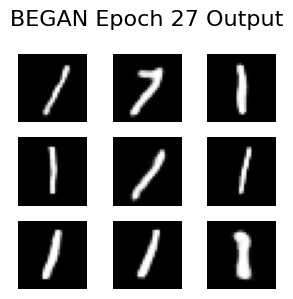

[27/30][0/937] Loss_D: 0.0410 Loss_G: 0.0317 M: 0.0452 k: 0.1622
[27/30][400/937] Loss_D: 0.0424 Loss_G: 0.0351 M: 0.0495 k: 0.1625
[27/30][800/937] Loss_D: 0.0412 Loss_G: 0.0364 M: 0.0504 k: 0.1630


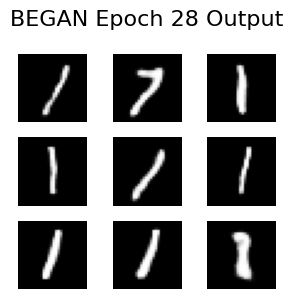

[28/30][0/937] Loss_D: 0.0415 Loss_G: 0.0328 M: 0.0476 k: 0.1631
[28/30][400/937] Loss_D: 0.0396 Loss_G: 0.0289 M: 0.0461 k: 0.1635
[28/30][800/937] Loss_D: 0.0396 Loss_G: 0.0349 M: 0.0484 k: 0.1639


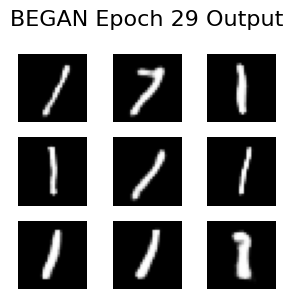

[29/30][0/937] Loss_D: 0.0401 Loss_G: 0.0321 M: 0.0457 k: 0.1639
[29/30][400/937] Loss_D: 0.0394 Loss_G: 0.0285 M: 0.0460 k: 0.1642
[29/30][800/937] Loss_D: 0.0383 Loss_G: 0.0286 M: 0.0452 k: 0.1646


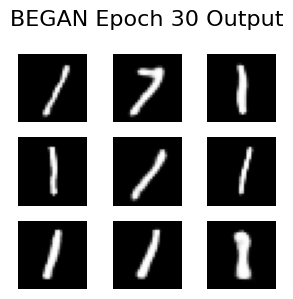

BEGAN Models saved.


In [9]:
for epoch in range(num_epochs):
    for i, data in enumerate(dataloader, 0):
        
        real = data[0].to(device)
        b_size = real.size(0)
        
        z = torch.randn(b_size, latent_dim, device=device)
        fake = netG(z)
        

        optimizerD.zero_grad()
        
        real_reconstructed = netD(real)
        d_loss_real = l1_loss(real_reconstructed, real)
        
        fake_reconstructed_D = netD(fake.detach())
        d_loss_fake = l1_loss(fake_reconstructed_D, fake.detach())
        
        d_loss = d_loss_real - k_t * d_loss_fake
        d_loss.backward()
        optimizerD.step()
        

        optimizerG.zero_grad()
        
        fake_reconstructed_G = netD(fake)
        g_loss = l1_loss(fake_reconstructed_G, fake)
        
        g_loss.backward()
        optimizerG.step()
        

        k_t = k_t + lambda_k * ((gamma * d_loss_real.item()) - g_loss.item())
        k_t = max(min(k_t, 1.0), 0.01)
        
        M = d_loss_real.item() + np.abs((gamma * d_loss_real.item()) - g_loss.item())
        
        G_losses.append(g_loss.item())
        D_losses.append(d_loss.item())
        M_values.append(M)
        k_values.append(k_t)
        
        if i % 400 == 0:
            print(f'[{epoch}/{num_epochs}][{i}/{len(dataloader)}] '
                  f'Loss_D: {d_loss.item():.4f} Loss_G: {g_loss.item():.4f} '
                  f'M: {M:.4f} k: {k_t:.4f}')

    with torch.no_grad():
        fake_images = netG(fixed_noise).detach().cpu()
    plot_images(fake_images[:9], num_cols=3, title=f"BEGAN Epoch {epoch + 1} Output")

torch.save(netG.state_dict(), 'began_generator.pth')
torch.save(netD.state_dict(), 'began_discriminator.pth')
print("BEGAN Models saved.")

**Analysis**

- loss Discriminator much lower than loss Generator and by D(x) we undertand that discriminator is stronger than generator. Still, gradient didn't vanish and generator updates.
- visually, the results are acceptable. Also we have a good mixture of numbers so mode collapase hasn't occured

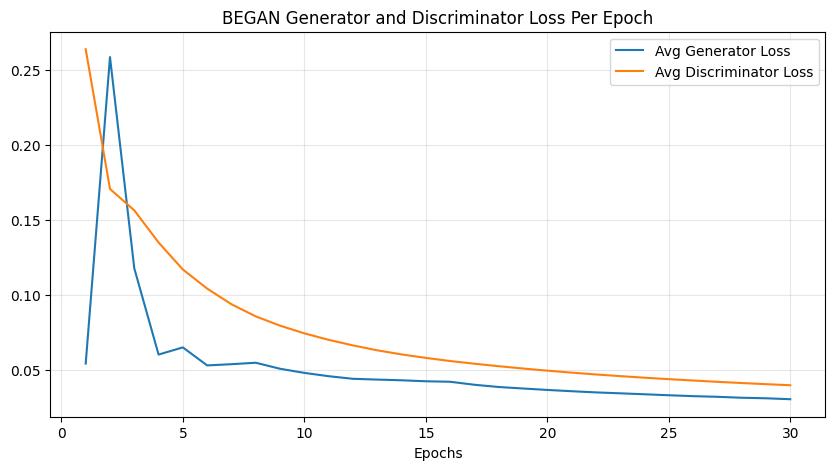

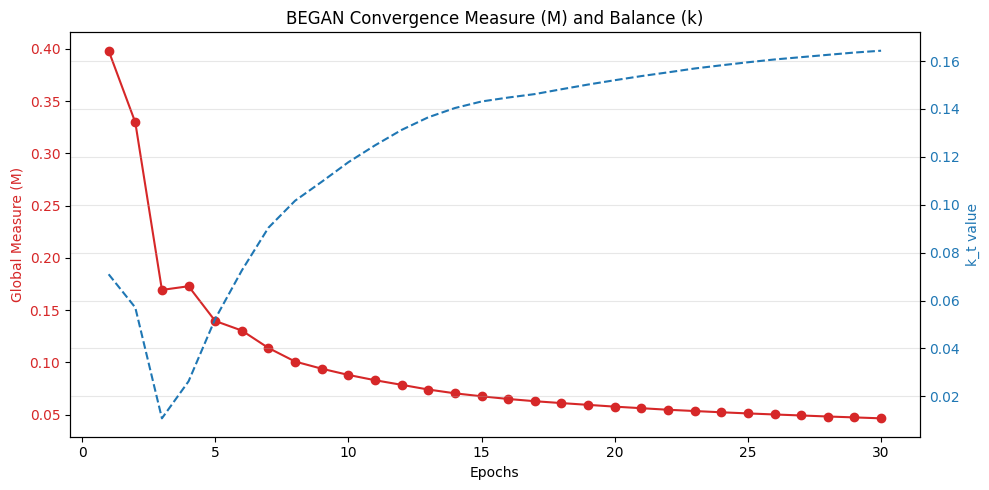

In [10]:
batches_per_epoch = len(dataloader)

G_losses_epoch = np.array(G_losses).reshape(num_epochs, batches_per_epoch).mean(axis=1)
D_losses_epoch = np.array(D_losses).reshape(num_epochs, batches_per_epoch).mean(axis=1)
M_epoch = np.array(M_values).reshape(num_epochs, batches_per_epoch).mean(axis=1)
k_epoch = np.array(k_values).reshape(num_epochs, batches_per_epoch).mean(axis=1)

plt.figure(figsize=(10, 5))
plt.title("BEGAN Generator and Discriminator Loss Per Epoch")
plt.plot(range(1, num_epochs + 1), G_losses_epoch, label="Avg Generator Loss")
plt.plot(range(1, num_epochs + 1), D_losses_epoch, label="Avg Discriminator Loss")
plt.xlabel("Epochs")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

fig, ax1 = plt.subplots(figsize=(10, 5))
plt.title("BEGAN Convergence Measure (M) and Balance (k)")

color = 'tab:red'
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Global Measure (M)', color=color)
ax1.plot(range(1, num_epochs + 1), M_epoch, color=color, label='M (Convergence)', marker='o')
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()  
color = 'tab:blue'
ax2.set_ylabel('k_t value', color=color)  
ax2.plot(range(1, num_epochs + 1), k_epoch, color=color, label='k_t', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  
plt.grid(True, alpha=0.3)
plt.show()

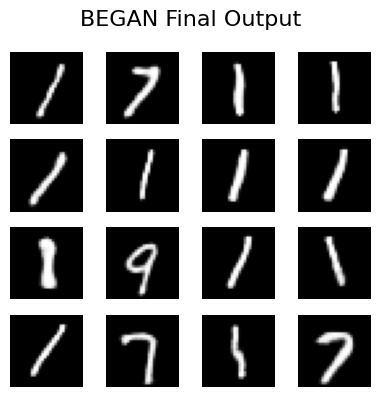

In [11]:
netG.eval()
with torch.no_grad():
    fake_display = netG(fixed_noise).detach().cpu()
plot_images(fake_display[:16], num_cols=4, title=f"BEGAN Final Output")



In [12]:
!pip install torch-fidelity
from torchmetrics.image.fid import FrechetInceptionDistance
from tqdm import tqdm
!pip install torch-fidelity
import math

def calculate_fid(generator, dataloader, device, num_samples=1000):

    print(f"Calculating FID over {num_samples} samples...")
    
    fid = FrechetInceptionDistance(feature=2048).to(device)
    generator.eval()
    
    samples_processed = 0
    expected_batches = math.ceil(num_samples / 64)

    for real_batch, _ in tqdm(dataloader, desc="Extracting Features", total=expected_batches):
        if samples_processed >= num_samples:
            break
            
        b_size = real_batch.size(0)
        
        real_images = ((real_batch + 1) / 2 * 255).byte().to(device)

        real_images = real_images.repeat(1, 3, 1, 1)
        
        with torch.no_grad():
            noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
            fake_batch = generator(noise)
            
        fake_images = ((fake_batch + 1) / 2 * 255).byte().to(device)
        fake_images = fake_images.repeat(1, 3, 1, 1)
        
        fid.update(real_images, real=True)
        fid.update(fake_images, real=False)
        
        samples_processed += b_size
        
    fid_score = fid.compute().item()
    print(f"\nFinal FID Score: {fid_score:.4f}")
    
    fid.reset() 
    return fid_score

naive_gan_fid = calculate_fid(netG, dataloader, device, num_samples=10000)

Calculating FID over 10000 samples...


Extracting Features: 100%|██████████| 157/157 [01:16<00:00,  2.06it/s]



Final FID Score: 58.0975
